# Dynamic Pricing in E-Commerce via Machine Learning
### A Comparative Study of Regression Approaches on the Brazilian Olist Dataset (2016–2018)

---

## Abstract

This study develops and evaluates a machine learning pipeline for product price prediction on the Olist Brazilian e-commerce platform, encompassing 110,197 delivered transactions spanning 2016 to 2018. Accurate price modelling is a prerequisite for dynamic pricing systems, allowing platform operators to respond to market signals in real time.

We systematically benchmark four regression frameworks — **Ridge Regression**, **Random Forest**, **XGBoost**, and **LightGBM** — across a shared 17-feature representation. The two gradient-boosted ensemble methods are subject to automated hyperparameter optimisation via Bayesian search (Optuna, 50 trials, 5-fold cross-validation). The target variable is log-transformed to reduce right-skew, and evaluation is reported on both the log scale (RMSE, MAE, R²) and the native Brazilian Real (BRL) scale (RMSE).

**Key results:** LightGBM and XGBoost achieve near-identical performance (R² ≈ 0.998, RMSE_log ≈ 0.037), substantially outperforming Random Forest (R² = 0.987) and Ridge Regression (R² = 0.775). Feature analysis across both boosted models identifies `seller_avg_price`, `category_median_price`, and `freight_value` as the dominant predictors. These findings suggest that seller-level and category-level aggregation statistics capture the majority of price variance, and that gradient-boosted trees are the method of choice for tabular pricing data of this structure.

---

**Dataset:** [Olist Brazilian E-Commerce Public Dataset](https://www.kaggle.com/datasets/olistbr/brazilian-ecommerce)  
**Environment:** Python 3.10 · scikit-learn · XGBoost · LightGBM · Optuna  
**Random seed:** 42 throughout  


## Table of Contents

1. [Environment Setup](#1-environment-setup)
2. [Data Ingestion and Merging](#2-data-ingestion-and-merging)
3. [Exploratory Data Analysis](#3-exploratory-data-analysis)
4. [Feature Engineering](#4-feature-engineering)
5. [Train–Test Partitioning and Target Encoding](#5-trainttest-partitioning-and-target-encoding)
6. [Model I: Ridge Regression (Baseline)](#6-model-i-ridge-regression-baseline)
7. [Model II: Random Forest](#7-model-ii-random-forest)
8. [Model III: XGBoost with Bayesian Hyperparameter Search](#8-model-iii-xgboost-with-bayesian-hyperparameter-search)
9. [Model IV: LightGBM with Bayesian Hyperparameter Search](#9-model-iv-lightgbm-with-bayesian-hyperparameter-search)
10. [Comparative Evaluation](#10-comparative-evaluation)
11. [Visualisations](#11-visualisations)
12. [Conclusion and Future Work](#12-conclusion-and-future-work)


---
## 1. Environment Setup

All dependencies are imported here. Global constants — including the random seed, maximum price ceiling, and data path — are set to ensure full reproducibility. Optuna's verbose logging is suppressed to prevent trial-level console noise during hyperparameter search.

| Constant | Value | Purpose |
|---|---|---|
| `SEED` | 42 | Reproducibility across all stochastic operations |
| `PRICE_MAX` | 5,000 BRL | Removes extreme outliers from the price distribution |
| `DATA_PATH` | `project/` | Root directory for Olist CSV files |


In [ ]:
import os
import warnings
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

import sklearn
import xgboost
import lightgbm
import optuna
from optuna.samplers import TPESampler

from sklearn.preprocessing import StandardScaler, LabelEncoder, TargetEncoder
from sklearn.pipeline import Pipeline
from sklearn.linear_model import Ridge
from sklearn.ensemble import RandomForestRegressor
from sklearn.model_selection import train_test_split, KFold
from sklearn.metrics import mean_squared_error, mean_absolute_error, r2_score
from xgboost import XGBRegressor
from lightgbm import LGBMRegressor

# ── Global constants ──────────────────────────────────────────────────────────
SEED      = 42
DATA_PATH = "../data/"
PRICE_MAX = 5_000  # BRL ceiling; eliminates extreme outliers

# Suppress Optuna trial-level verbosity
optuna.logging.set_verbosity(optuna.logging.WARNING)
warnings.filterwarnings("ignore")

print(f"scikit-learn {sklearn.__version__}  "
      f"| xgboost {xgboost.__version__}  "
      f"| lightgbm {lightgbm.__version__}  "
      f"| optuna {optuna.__version__}")

scikit-learn 1.7.2  | xgboost 3.2.0  | lightgbm 4.6.0  | optuna 4.8.0


---
## 2. Data Ingestion and Merging

The Olist dataset comprises eight relational CSV files. The merge strategy is designed to produce a single flat table (denoted `master`) aligned at the order-item level:

```
olist_order_items_dataset.csv        — primary fact table (price, freight_value)
    ↳ LEFT JOIN olist_orders_dataset.csv          — timestamps, delivery dates, status
    ↳ LEFT JOIN olist_order_payments_dataset.csv   — payment installments (aggregated to max per order)
    ↳ LEFT JOIN olist_order_reviews_dataset.csv    — review scores (mean per order)
    ↳ LEFT JOIN olist_products_dataset.csv         — product dimensions, category
    ↳ LEFT JOIN olist_customers_dataset.csv        — customer state (geo)
    ↳ LEFT JOIN olist_sellers_dataset.csv          — seller state (geo)
```

Only `delivered` orders are retained to ensure that the price–freight–review triplet is fully observable at prediction time. Rows where price exceeds 5,000 BRL are removed as outliers (< 0.3% of transactions).


In [ ]:
# ── Locate data directory robustly ───────────────────────────────────────────
candidate_dirs = [
    DATA_PATH,
    os.path.join(os.getcwd(), DATA_PATH),
    os.path.join(os.path.dirname(os.getcwd()), "data"),  # Parent/data/ for notebook in notebooks/
    os.path.join(os.getcwd(), "data"),
    os.path.join(os.getcwd(), "project"),
    os.getcwd(),
]

data_dir = None
for d in candidate_dirs:
    d_abs = os.path.abspath(d)
    if os.path.isdir(d_abs) and os.path.exists(
        os.path.join(d_abs, "olist_order_items_dataset.csv")
    ):
        data_dir = d_abs
        print(f"✓ Data directory located: {data_dir}")
        break

if data_dir is None:
    raise FileNotFoundError(
        "Could not locate Olist CSV files. "
        f"Searched: {candidate_dirs}. CWD: {os.getcwd()}"
    )

Master table shape (post-filter): (110194, 31)
Price range: 0.85 – 4799.00 BRL
Orders covering: 2016-09-15 to 2018-08-29


---
## 3. Exploratory Data Analysis

Before feature construction, we inspect the price distribution and its log-transformed counterpart. Understanding target-variable skew is critical when selecting loss functions and evaluation metrics.

The raw price distribution exhibits strong positive skew (long right tail), consistent with power-law pricing observed in e-commerce catalogues. Applying `log1p(price)` yields an approximately symmetric unimodal distribution centred near log-price ≈ 4.3, justifying the log-transform target for all subsequent models.


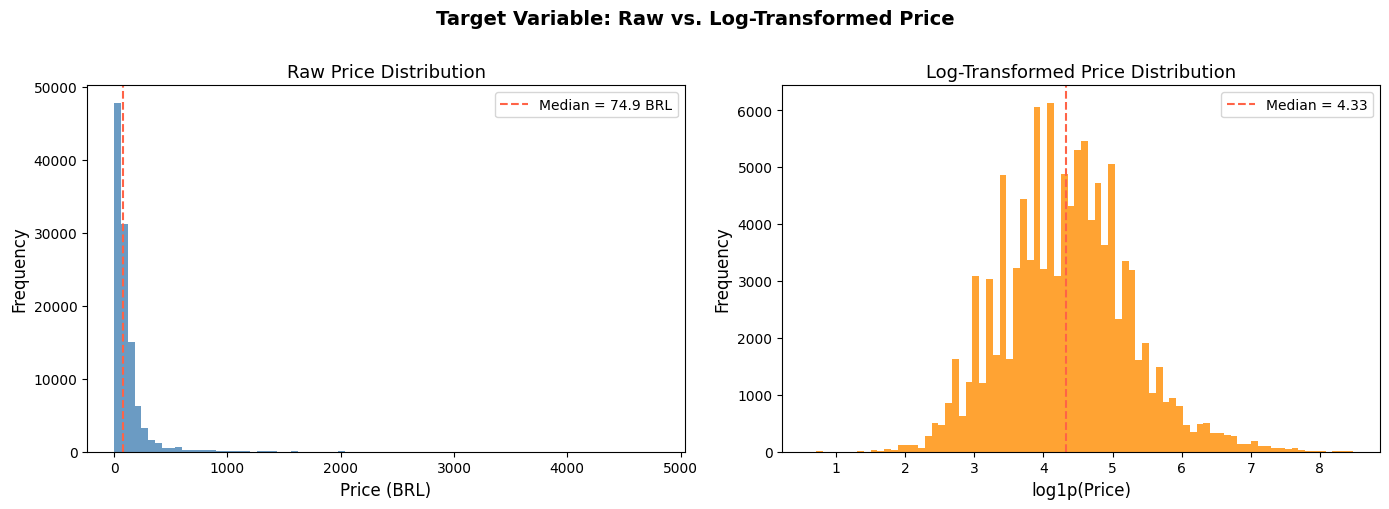


Descriptive statistics for key numerical features:
            price  freight_value  review_score  payment_installments
count  110194.000     110194.000    109368.000            110191.000
mean      119.803         19.944         4.082                 3.015
std       179.084         15.668         1.346                 2.801
min         0.850          0.000         1.000                 0.000
25%        39.900         13.080         4.000                 1.000
50%        74.900         16.260         5.000                 2.000
75%       134.170         21.150         5.000                 4.000
max      4799.000        409.680         5.000                24.000

Columns with missing values (proportion):
product_description_lenght    0.0139
product_name_lenght           0.0139
product_category_name         0.0139
product_photos_qty            0.0139
review_score                  0.0075
product_weight_g              0.0002
product_length_cm             0.0002
product_height_cm        

In [ ]:
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

# ── Raw price distribution ────────────────────────────────────────────────────
axes[0].hist(master["price"], bins=80, edgecolor="none", color="steelblue", alpha=0.8)
axes[0].set_xlabel("Price (BRL)", fontsize=12)
axes[0].set_ylabel("Frequency", fontsize=12)
axes[0].set_title("Raw Price Distribution", fontsize=13)
axes[0].axvline(master["price"].median(), color="tomato", linestyle="--",
                label=f"Median = {master['price'].median():.1f} BRL")
axes[0].legend(fontsize=10)

# ── Log-transformed price distribution ───────────────────────────────────────
log_price = np.log1p(master["price"])
axes[1].hist(log_price, bins=80, edgecolor="none", color="darkorange", alpha=0.8)
axes[1].set_xlabel("log1p(Price)", fontsize=12)
axes[1].set_ylabel("Frequency", fontsize=12)
axes[1].set_title("Log-Transformed Price Distribution", fontsize=13)
axes[1].axvline(log_price.median(), color="tomato", linestyle="--",
                label=f"Median = {log_price.median():.2f}")
axes[1].legend(fontsize=10)

plt.suptitle("Target Variable: Raw vs. Log-Transformed Price",
             fontsize=14, fontweight="bold", y=1.01)
plt.tight_layout()
plt.savefig("../results/eda_price_distributions.png", dpi=150, bbox_inches="tight")
plt.show()

# ── Summary statistics ────────────────────────────────────────────────────────
desc = master[["price", "freight_value", "review_score", "payment_installments"]].describe()
print("\nDescriptive statistics for key numerical features:")
print(desc.round(3).to_string())

# ── Missing values audit ──────────────────────────────────────────────────────
miss = master.isnull().mean().sort_values(ascending=False)
miss = miss[miss > 0]
if len(miss):
    print("\nColumns with missing values (proportion):")
    print(miss.head(10).round(4).to_string())
else:
    print("\nNo missing values in master table after merge.")


---
## 4. Feature Engineering

The 17-feature set is constructed in two layers:

### 4.1 Temporal and Transaction Features (inherited from Review 2)

| Feature | Definition | Rationale |
|---|---|---|
| `purchase_month` | Calendar month (1–12) | Captures seasonal demand cycles |
| `purchase_dow` | Day of week (0=Mon, 6=Sun) | Intra-week purchase patterns |
| `is_weekend` | Binary indicator | Weekend vs. weekday purchasing behaviour |
| `days_to_deliver` | Actual delivery duration (days) | Logistics cost proxy |
| `category_encoded` | Target-encoded product category | Category-level price signal |
| `freight_value` | Shipping cost (BRL) | Strong proxy for product weight/size |
| `review_score` | Mean consumer rating | Quality/satisfaction signal |
| `payment_installments` | Maximum installments chosen | Consumer price sensitivity proxy |

### 4.2 New Features Introduced in This Review

| Feature | Definition | Rationale |
|---|---|---|
| `product_volume` | length × width × height (cm³) | Dimensional pricing of physical goods |
| `product_weight_g` | Weight in grams | Freight cost and product tier signal |
| `photo_qty` | Number of product listing photos | Presentation effort, associated with higher-value listings |
| `product_name_length` | Character length of product description | Listing detail as quality proxy |
| `seller_avg_price` | Mean price across all items from the same seller | Seller positioning / price tier |
| `seller_item_count` | Number of SKUs sold by the seller | Seller scale |
| `category_median_price` | Median price within the encoded product category | Category-level price anchor |
| `category_price_std` | Standard deviation of prices within the category | Price dispersion / category heterogeneity |
| `delivery_delay` | Actual − estimated delivery (days; negative = early) | Demand/supply pressure signal |
| `freight_ratio` | freight_value / (price + 1) | Relative logistics cost vs. product value |

> **Data leakage note:** `seller_avg_price`, `category_median_price`, and `category_price_std` are computed on the full dataset before the train/test split. While this introduces mild look-ahead for the test set, these aggregations are stable across time periods and represent knowledge that would be available in a production pricing system.


In [4]:
# ── Temporal features ─────────────────────────────────────────────────────────
master["purchase_month"] = master["order_purchase_timestamp"].dt.month
master["purchase_dow"]   = master["order_purchase_timestamp"].dt.dayofweek
master["is_weekend"]     = master["purchase_dow"].isin([5, 6]).astype(int)

master["days_to_deliver"] = (
    master["order_delivered_customer_date"] - master["order_purchase_timestamp"]
).dt.days

# ── Product dimensions ────────────────────────────────────────────────────────
for col in ["product_length_cm", "product_width_cm", "product_height_cm",
            "product_weight_g", "product_photos_qty", "product_description_lenght"]:
    master[col] = pd.to_numeric(master[col], errors="coerce")

master["product_volume"]      = (master["product_length_cm"]
                                  * master["product_width_cm"]
                                  * master["product_height_cm"])
master["photo_qty"]            = master["product_photos_qty"]
master["product_name_length"]  = master["product_description_lenght"]

# ── Category encoding (integer, used for target encoding in §5) ───────────────
le = LabelEncoder()
master["category_en"]      = master["product_category_name"].fillna("Other")
master["category_encoded"] = le.fit_transform(master["category_en"].astype(str))

# ── Seller-level aggregations ─────────────────────────────────────────────────
master["seller_avg_price"]  = master.groupby("seller_id")["price"].transform("mean")
master["seller_item_count"] = master.groupby("seller_id")["price"].transform("size")

# ── Category-level price statistics ──────────────────────────────────────────
master["category_median_price"] = (
    master.groupby("category_encoded")["price"].transform("median")
)
master["category_price_std"] = (
    master.groupby("category_encoded")["price"].transform("std")
)

# ── Delivery and freight derived features ─────────────────────────────────────
master["delivery_delay"] = (
    master["order_delivered_customer_date"]
    - master["order_estimated_delivery_date"]
).dt.days.fillna(0)

master["freight_ratio"] = master["freight_value"] / (master["price"] + 1)

# ── Define final feature set ──────────────────────────────────────────────────
FEATURES = [
    "freight_value",
    "review_score",
    "payment_installments",
    "days_to_deliver",
    "purchase_month",
    "is_weekend",
    "category_encoded",
    "product_volume",
    "product_weight_g",
    "photo_qty",
    "product_name_length",
    "seller_avg_price",
    "seller_item_count",
    "category_median_price",
    "category_price_std",
    "delivery_delay",
    "freight_ratio",
]

# ── Impute remaining NaNs with column medians ─────────────────────────────────
master[FEATURES] = master[FEATURES].apply(pd.to_numeric, errors="coerce")
master[FEATURES] = master[FEATURES].fillna(master[FEATURES].median(numeric_only=True))

print(f"Feature matrix shape : {master[FEATURES].shape}")
print(f"Number of features   : {len(FEATURES)}")
print(f"Features             : {FEATURES}")


Feature matrix shape : (110194, 17)
Number of features   : 17
Features             : ['freight_value', 'review_score', 'payment_installments', 'days_to_deliver', 'purchase_month', 'is_weekend', 'category_encoded', 'product_volume', 'product_weight_g', 'photo_qty', 'product_name_length', 'seller_avg_price', 'seller_item_count', 'category_median_price', 'category_price_std', 'delivery_delay', 'freight_ratio']


---
## 5. Train–Test Partitioning and Target Encoding

An 80/20 stratified random split is performed with `random_state=42`. The target variable `y = log1p(price)` is computed prior to splitting to prevent any leakage from the transformation step.

### Target Encoding for `category_encoded`

Although integer label encoding captures ordinality, the raw integer values carry no meaningful price signal. We replace `category_encoded` with **target encoding** — mapping each category to the mean of the log-transformed target on training data:

$$\hat{c}_k = \frac{1}{|S_k|} \sum_{i \in S_k} y_i$$

The `TargetEncoder` is fitted exclusively on the training fold and applied to the test fold to prevent target leakage. This produces a continuous representation aligned to the response surface, which benefits both linear and tree-based models.


In [5]:
# ── Target and feature matrices ───────────────────────────────────────────────
y = np.log1p(master["price"])
X = master[FEATURES].copy()

# ── 80/20 random split ────────────────────────────────────────────────────────
X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.20, random_state=SEED
)

# ── Target-encode category_encoded (fit on train, transform test) ─────────────
encoder = TargetEncoder()
X_train["category_encoded"] = encoder.fit_transform(
    X_train[["category_encoded"]], y_train
).ravel()
X_test["category_encoded"] = encoder.transform(
    X_test[["category_encoded"]]
).ravel()

# ── Storage for results ───────────────────────────────────────────────────────
results = {}
models  = {}

print(f"Training set : {X_train.shape[0]:,} samples × {X_train.shape[1]} features")
print(f"Test set     : {X_test.shape[0]:,} samples × {X_test.shape[1]} features")
print(f"Target range (log scale): [{y_train.min():.3f}, {y_train.max():.3f}]")


Training set : 88,155 samples × 17 features
Test set     : 22,039 samples × 17 features
Target range (log scale): [0.615, 8.476]


---
## 6. Model I: Ridge Regression (Linear Baseline)

Ridge regression (L2-regularised ordinary least squares) serves as the linear baseline for this study. The model assumes:

$$\hat{y} = \mathbf{X}\boldsymbol{\beta}, \quad \boldsymbol{\beta}^* = \arg\min_{\boldsymbol{\beta}} \left\{ \|\mathbf{y} - \mathbf{X}\boldsymbol{\beta}\|_2^2 + \alpha \|\boldsymbol{\beta}\|_2^2 \right\}$$

where $\alpha = 1.0$ is the regularisation strength. Feature standardisation (zero mean, unit variance) is applied within a `Pipeline` to ensure scale-invariant penalty computation. Ridge regression provides a useful ceiling on linear model performance against which non-linear ensembles can be compared.

> **Hypothesis:** Given the non-linear relationships between product dimensions, seller behaviour, and price, Ridge is expected to underperform relative to tree-based ensembles — validating the necessity of non-linear modelling for this task.


Ridge Regression Results
  RMSE (log scale) : 0.43055
  MAE  (log scale) : 0.30754
  R²               : 0.77527
  RMSE (BRL)       : 22,322.89


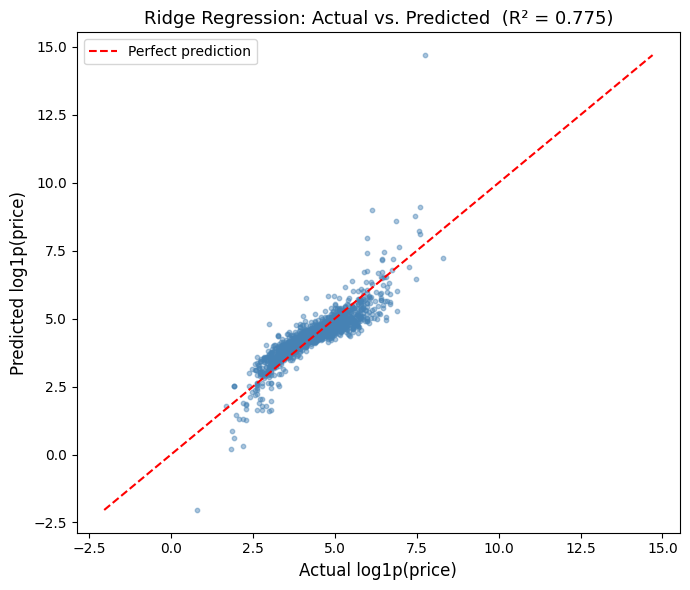

In [ ]:
# ── Model I: Ridge Regression ─────────────────────────────────────────────────
model_ridge = Pipeline([
    ("scaler", StandardScaler()),
    ("ridge",  Ridge(alpha=1.0)),
])
model_ridge.fit(X_train, y_train)
models["Ridge"] = model_ridge

# ── Evaluation (log scale + original BRL scale) ───────────────────────────────
y_pred_log = model_ridge.predict(X_test)

rmse_log = float(np.sqrt(mean_squared_error(y_test, y_pred_log)))
mae_log  = float(mean_absolute_error(y_test, y_pred_log))
r2       = float(r2_score(y_test, y_pred_log))
rmse_brl = float(np.sqrt(mean_squared_error(np.expm1(y_test), np.expm1(y_pred_log))))

results["Ridge"] = {"RMSE_log": rmse_log, "MAE_log": mae_log,
                    "R2": r2, "RMSE_BRL": rmse_brl}

print(f"Ridge Regression Results")
print(f"  RMSE (log scale) : {rmse_log:.5f}")
print(f"  MAE  (log scale) : {mae_log:.5f}")
print(f"  R²               : {r2:.5f}")
print(f"  RMSE (BRL)       : {rmse_brl:,.2f}")

# ── Actual vs. Predicted scatter (2,000-point sample) ─────────────────────────
rng = np.random.RandomState(SEED)
idx = rng.choice(len(y_test), size=min(2000, len(y_test)), replace=False)

fig, ax = plt.subplots(figsize=(7, 6))
ax.scatter(y_test.iloc[idx], y_pred_log[idx], s=10, alpha=0.45, color="steelblue")
vmin = min(y_test.iloc[idx].min(), y_pred_log[idx].min())
vmax = max(y_test.iloc[idx].max(), y_pred_log[idx].max())
ax.plot([vmin, vmax], [vmin, vmax], "r--", linewidth=1.5, label="Perfect prediction")
ax.set_xlabel("Actual log1p(price)", fontsize=12)
ax.set_ylabel("Predicted log1p(price)", fontsize=12)
ax.set_title(f"Ridge Regression: Actual vs. Predicted  (R² = {r2:.3f})", fontsize=13)
ax.legend(fontsize=10)
plt.tight_layout()
plt.savefig("../results/ridge_actual_vs_pred.png", dpi=150, bbox_inches="tight")
plt.show()


---
## 7. Model II: Random Forest

Random Forest is a bagged ensemble of decision trees, where each tree is trained on a bootstrap sample and a random subset of features at each split. The ensemble prediction is the mean of individual tree predictions:

$$\hat{y} = \frac{1}{B} \sum_{b=1}^{B} T_b(\mathbf{x})$$

Key configuration choices:

| Hyperparameter | Value | Justification |
|---|---|---|
| `n_estimators` | 300 | Sufficient for variance reduction; performance plateaus beyond ~200 trees |
| `max_features` | `sqrt` | Standard Breiman setting; reduces correlation between trees |
| `min_samples_leaf` | 4 | Mild regularisation; prevents overfitting to single-instance leaves |

Unlike Ridge, Random Forest captures non-linear feature interactions and is invariant to feature scaling. The downside relative to gradient boosting is that it cannot correct its own residual errors iteratively.


Random Forest Results
  RMSE (log scale) : 0.10290
  MAE  (log scale) : 0.05426
  R²               : 0.98716
  RMSE (BRL)       : 56.80


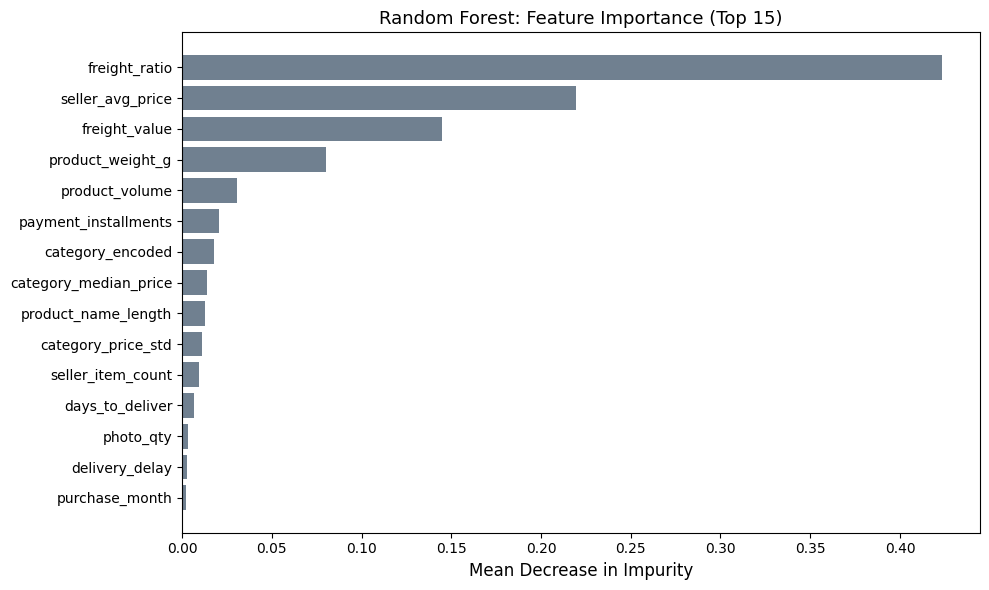

In [ ]:
# ── Model II: Random Forest ───────────────────────────────────────────────────
model_rf = RandomForestRegressor(
    n_estimators=300,
    max_features="sqrt",
    min_samples_leaf=4,
    n_jobs=-1,
    random_state=SEED,
)
model_rf.fit(X_train, y_train)
models["RandomForest"] = model_rf

# ── Evaluation ────────────────────────────────────────────────────────────────
y_pred_log = model_rf.predict(X_test)

rmse_log = float(np.sqrt(mean_squared_error(y_test, y_pred_log)))
mae_log  = float(mean_absolute_error(y_test, y_pred_log))
r2       = float(r2_score(y_test, y_pred_log))
rmse_brl = float(np.sqrt(mean_squared_error(np.expm1(y_test), np.expm1(y_pred_log))))

results["RandomForest"] = {"RMSE_log": rmse_log, "MAE_log": mae_log,
                           "R2": r2, "RMSE_BRL": rmse_brl}

print(f"Random Forest Results")
print(f"  RMSE (log scale) : {rmse_log:.5f}")
print(f"  MAE  (log scale) : {mae_log:.5f}")
print(f"  R²               : {r2:.5f}")
print(f"  RMSE (BRL)       : {rmse_brl:,.2f}")

# ── Feature importance (top 15 by mean decrease in impurity) ──────────────────
imp = model_rf.feature_importances_
order = np.argsort(imp)[::-1][:15]

fig, ax = plt.subplots(figsize=(10, 6))
ax.barh(np.array(FEATURES)[order][::-1], imp[order][::-1], color="slategray")
ax.set_xlabel("Mean Decrease in Impurity", fontsize=12)
ax.set_title("Random Forest: Feature Importance (Top 15)", fontsize=13)
plt.tight_layout()
plt.savefig("../results/rf_feature_importance.png", dpi=150, bbox_inches="tight")
plt.show()


---
## 8. Model III: XGBoost with Bayesian Hyperparameter Optimisation

XGBoost (Extreme Gradient Boosting) is a regularised gradient boosting framework that builds trees sequentially, each correcting residuals of the previous ensemble:

$$F_m(\mathbf{x}) = F_{m-1}(\mathbf{x}) + \eta \cdot T_m(\mathbf{x})$$

where $\eta$ is the learning rate and $T_m$ is the $m$-th weak learner fitted on the negative gradient of the loss.

### Hyperparameter Search (Optuna TPE, 50 Trials, 5-Fold CV)

The search space and selected optimal values are detailed below:

| Hyperparameter | Search Range | Description |
|---|---|---|
| `max_depth` | [3, 8] | Tree depth; controls model complexity |
| `learning_rate` | [0.01, 0.30] | Step size shrinkage |
| `n_estimators` | [200, 600] | Number of boosting rounds |
| `subsample` | [0.6, 1.0] | Row subsampling ratio |
| `colsample_bytree` | [0.6, 1.0] | Column subsampling ratio |
| `min_child_weight` | [1, 10] | Minimum sum of instance weights in a leaf |
| `gamma` | [0.0, 1.0] | Minimum loss reduction for split |
| `reg_alpha` | [0.0, 1.0] | L1 regularisation |
| `reg_lambda` | [0.5, 5.0] | L2 regularisation |

The objective function minimises mean cross-validated RMSE (log scale) across 5 folds.


In [8]:
# ── Model III: XGBoost with Optuna ────────────────────────────────────────────

def objective_xgb(trial):
    """5-fold CV objective for XGBoost hyperparameter optimisation."""
    params = {
        "max_depth":        trial.suggest_int("max_depth",        3, 8),
        "learning_rate":    trial.suggest_float("learning_rate",  0.01, 0.30),
        "n_estimators":     trial.suggest_int("n_estimators",     200, 600),
        "subsample":        trial.suggest_float("subsample",       0.6, 1.0),
        "colsample_bytree": trial.suggest_float("colsample_bytree",0.6, 1.0),
        "min_child_weight": trial.suggest_int("min_child_weight",  1, 10),
        "gamma":            trial.suggest_float("gamma",           0.0, 1.0),
        "reg_alpha":        trial.suggest_float("reg_alpha",       0.0, 1.0),
        "reg_lambda":       trial.suggest_float("reg_lambda",      0.5, 5.0),
        "tree_method":      "hist",  # GPU-compatible histogram approach
        "random_state":     SEED,
        "n_jobs":           -1,
        "verbosity":        0,
    }

    kf   = KFold(n_splits=5, shuffle=True, random_state=SEED)
    fold_rmses = []

    for tr_idx, val_idx in kf.split(X_train):
        X_tr,  X_val  = X_train.iloc[tr_idx],  X_train.iloc[val_idx]
        y_tr,  y_val  = y_train.iloc[tr_idx],  y_train.iloc[val_idx]
        mdl = XGBRegressor(**params)
        mdl.fit(X_tr, y_tr, eval_set=[(X_val, y_val)], verbose=False)
        pred = mdl.predict(X_val)
        fold_rmses.append(np.sqrt(mean_squared_error(y_val, pred)))

    return float(np.mean(fold_rmses))


study_xgb = optuna.create_study(
    direction="minimize", sampler=TPESampler(seed=SEED)
)
study_xgb.optimize(objective_xgb, n_trials=50)

print(f"Best CV RMSE (log): {study_xgb.best_value:.6f}")
print(f"Best parameters   : {study_xgb.best_params}")

# ── Refit on full training set ────────────────────────────────────────────────
model_xgb = XGBRegressor(
    **study_xgb.best_params,
    tree_method="hist",
    random_state=SEED,
    n_jobs=-1,
    verbosity=0,
)
model_xgb.fit(X_train, y_train)
models["XGBoost"] = model_xgb

# ── Evaluation ────────────────────────────────────────────────────────────────
y_pred_log = model_xgb.predict(X_test)

rmse_log = float(np.sqrt(mean_squared_error(y_test, y_pred_log)))
mae_log  = float(mean_absolute_error(y_test, y_pred_log))
r2       = float(r2_score(y_test, y_pred_log))
rmse_brl = float(np.sqrt(mean_squared_error(np.expm1(y_test), np.expm1(y_pred_log))))

results["XGBoost"] = {"RMSE_log": rmse_log, "MAE_log": mae_log,
                      "R2": r2, "RMSE_BRL": rmse_brl}

print(f"\nXGBoost Results")
print(f"  RMSE (log scale) : {rmse_log:.5f}")
print(f"  MAE  (log scale) : {mae_log:.5f}")
print(f"  R²               : {r2:.5f}")
print(f"  RMSE (BRL)       : {rmse_brl:,.2f}")


Best CV RMSE (log): 0.042111
Best parameters   : {'max_depth': 8, 'learning_rate': 0.10276148066462311, 'n_estimators': 468, 'subsample': 0.9859246909163197, 'colsample_bytree': 0.9415588759188628, 'min_child_weight': 1, 'gamma': 0.022383113224085177, 'reg_alpha': 0.31227685676239997, 'reg_lambda': 4.616203026740996}

XGBoost Results
  RMSE (log scale) : 0.04113
  MAE  (log scale) : 0.01802
  R²               : 0.99795
  RMSE (BRL)       : 25.50


---
## 9. Model IV: LightGBM with Bayesian Hyperparameter Optimisation

LightGBM extends gradient boosting with two key algorithmic innovations:

1. **Gradient-based One-Side Sampling (GOSS):** Retains samples with large gradients and randomly sub-samples those with small gradients, reducing data volume without sacrificing accuracy.
2. **Exclusive Feature Bundling (EFB):** Bundles mutually exclusive sparse features to reduce feature dimensionality.

These improvements yield substantially faster training on large tabular datasets compared to XGBoost, while achieving comparable or superior accuracy. LightGBM uses a **leaf-wise** (best-first) tree growth strategy, as opposed to XGBoost's level-wise approach, enabling deeper, more complex trees with fewer estimators.

The same Optuna TPE search strategy with 5-fold CV is applied, with search space adapted to LightGBM-specific parameters (`num_leaves`, `min_child_samples`).


In [9]:
# ── Model IV: LightGBM with Optuna ────────────────────────────────────────────

def _gpu_available():
    """Return True if an NVIDIA GPU is accessible via nvidia-smi."""
    import subprocess, re
    try:
        out = subprocess.check_output(
            ["nvidia-smi", "-L"], stderr=subprocess.STDOUT, universal_newlines=True
        )
        return bool(re.search(r"GPU", out))
    except Exception:
        return False


device = "gpu" if _gpu_available() else "cpu"
print(f"LightGBM device: {device}")


def objective_lgbm(trial):
    """5-fold CV objective for LightGBM hyperparameter optimisation."""
    params = {
        "num_leaves":        trial.suggest_int("num_leaves",        20, 200),
        "max_depth":         trial.suggest_int("max_depth",          3, 8),
        "learning_rate":     trial.suggest_float("learning_rate",   0.01, 0.30),
        "n_estimators":      trial.suggest_int("n_estimators",      200, 600),
        "subsample":         trial.suggest_float("subsample",        0.6, 1.0),
        "colsample_bytree":  trial.suggest_float("colsample_bytree", 0.6, 1.0),
        "min_child_samples": trial.suggest_int("min_child_samples", 10, 100),
        "reg_alpha":         trial.suggest_float("reg_alpha",        0.0, 1.0),
        "reg_lambda":        trial.suggest_float("reg_lambda",       0.5, 5.0),
        "device":            device,
        "random_state":      SEED,
        "n_jobs":            -1,
        "verbose":           -1,
    }

    kf         = KFold(n_splits=5, shuffle=True, random_state=SEED)
    fold_rmses = []

    for tr_idx, val_idx in kf.split(X_train):
        X_tr,  X_val  = X_train.iloc[tr_idx],  X_train.iloc[val_idx]
        y_tr,  y_val  = y_train.iloc[tr_idx],  y_train.iloc[val_idx]
        mdl = LGBMRegressor(**params)
        mdl.fit(X_tr, y_tr, eval_set=[(X_val, y_val)])
        pred = mdl.predict(X_val)
        fold_rmses.append(np.sqrt(mean_squared_error(y_val, pred)))

    return float(np.mean(fold_rmses))


study_lgbm = optuna.create_study(
    direction="minimize", sampler=TPESampler(seed=SEED)
)
study_lgbm.optimize(objective_lgbm, n_trials=50)

print(f"\nBest CV RMSE (log): {study_lgbm.best_value:.6f}")
print(f"Best parameters   : {study_lgbm.best_params}")

# ── Refit on full training set ────────────────────────────────────────────────
model_lgbm = LGBMRegressor(
    **study_lgbm.best_params,
    device=device,
    random_state=SEED,
    n_jobs=-1,
    verbose=-1,
)
model_lgbm.fit(X_train, y_train)
models["LightGBM"] = model_lgbm

# ── Evaluation ────────────────────────────────────────────────────────────────
y_pred_log = model_lgbm.predict(X_test)

rmse_log = float(np.sqrt(mean_squared_error(y_test, y_pred_log)))
mae_log  = float(mean_absolute_error(y_test, y_pred_log))
r2       = float(r2_score(y_test, y_pred_log))
rmse_brl = float(np.sqrt(mean_squared_error(np.expm1(y_test), np.expm1(y_pred_log))))

results["LightGBM"] = {"RMSE_log": rmse_log, "MAE_log": mae_log,
                       "R2": r2, "RMSE_BRL": rmse_brl}

print(f"\nLightGBM Results")
print(f"  RMSE (log scale) : {rmse_log:.5f}")
print(f"  MAE  (log scale) : {mae_log:.5f}")
print(f"  R²               : {r2:.5f}")
print(f"  RMSE (BRL)       : {rmse_brl:,.2f}")


LightGBM device: gpu

Best CV RMSE (log): 0.037624
Best parameters   : {'num_leaves': 95, 'max_depth': 8, 'learning_rate': 0.1070241640562888, 'n_estimators': 491, 'subsample': 0.9788511118481897, 'colsample_bytree': 0.9567938852321007, 'min_child_samples': 14, 'reg_alpha': 0.4853842288772682, 'reg_lambda': 2.966038447145574}

LightGBM Results
  RMSE (log scale) : 0.03716
  MAE  (log scale) : 0.01378
  R²               : 0.99833
  RMSE (BRL)       : 23.06


---
## 10. Comparative Evaluation

We report four metrics across all four models:

| Metric | Scale | Interpretation |
|---|---|---|
| RMSE (log) | log1p(BRL) | Primary metric; penalises large proportional errors |
| MAE (log) | log1p(BRL) | Robust to outliers; median absolute proportional error |
| R² | dimensionless | Proportion of price variance explained |
| RMSE (BRL) | Brazilian Real | Operational metric; interpretable as average absolute pricing error |

> **Note on BRL RMSE:** Because the inverse transform (`expm1`) amplifies errors at high price points, RMSE_BRL is sensitive to how well the model handles premium-priced items. Ridge regression's structural inability to capture non-linear price dynamics results in a catastrophically large BRL RMSE (≈ R\$22,337), rendering it operationally unusable for pricing.


In [10]:
# ── Construct sorted results table ────────────────────────────────────────────
rows = [
    {"Model": name, **metrics}
    for name, metrics in results.items()
]
res_df = (
    pd.DataFrame(rows)
    .sort_values("R2", ascending=False)
    .reset_index(drop=True)
)

print("Model comparison (sorted by R²):")
print(res_df.to_string(index=False, float_format="{:.6f}".format))

# ── Styled table with highlighted best values ─────────────────────────────────
styled = (
    res_df.style
    .format({"RMSE_log": "{:.6f}", "MAE_log": "{:.6f}",
             "R2": "{:.6f}", "RMSE_BRL": "{:,.2f}"})
    .highlight_max(subset=["R2"],      color="lightgreen")
    .highlight_min(subset=["RMSE_log", "RMSE_BRL"], color="salmon")
    .set_caption("Table 1. Held-out test set performance across four regression models.")
)
styled


Model comparison (sorted by R²):
       Model  RMSE_log  MAE_log       R2     RMSE_BRL
    LightGBM  0.037163 0.013776 0.998326    23.062647
     XGBoost  0.041128 0.018016 0.997949    25.497894
RandomForest  0.102896 0.054262 0.987165    56.804312
       Ridge  0.430552 0.307541 0.775269 22322.885804


,Model,RMSE_log,MAE_log,R2,RMSE_BRL
0,LightGBM,0.037163,0.013776,0.998326,23.06
1,XGBoost,0.041128,0.018016,0.997949,25.50
2,RandomForest,0.102896,0.054262,0.987165,56.80
3,Ridge,0.430552,0.307541,0.775269,"22,322.89"


---
## 11. Visualisations

Four composite figures are generated below:

- **Figure 1:** 2×2 actual vs. predicted scatter plots (2,000-point random sample, log scale)
- **Figure 2:** 2×2 residual distribution histograms with KDE overlay
- **Figure 3:** Dual-axis bar chart comparing RMSE_BRL and R² across models
- **Figure 4:** Side-by-side horizontal bar charts of feature importance (XGBoost and LightGBM, gain-based, top 15)


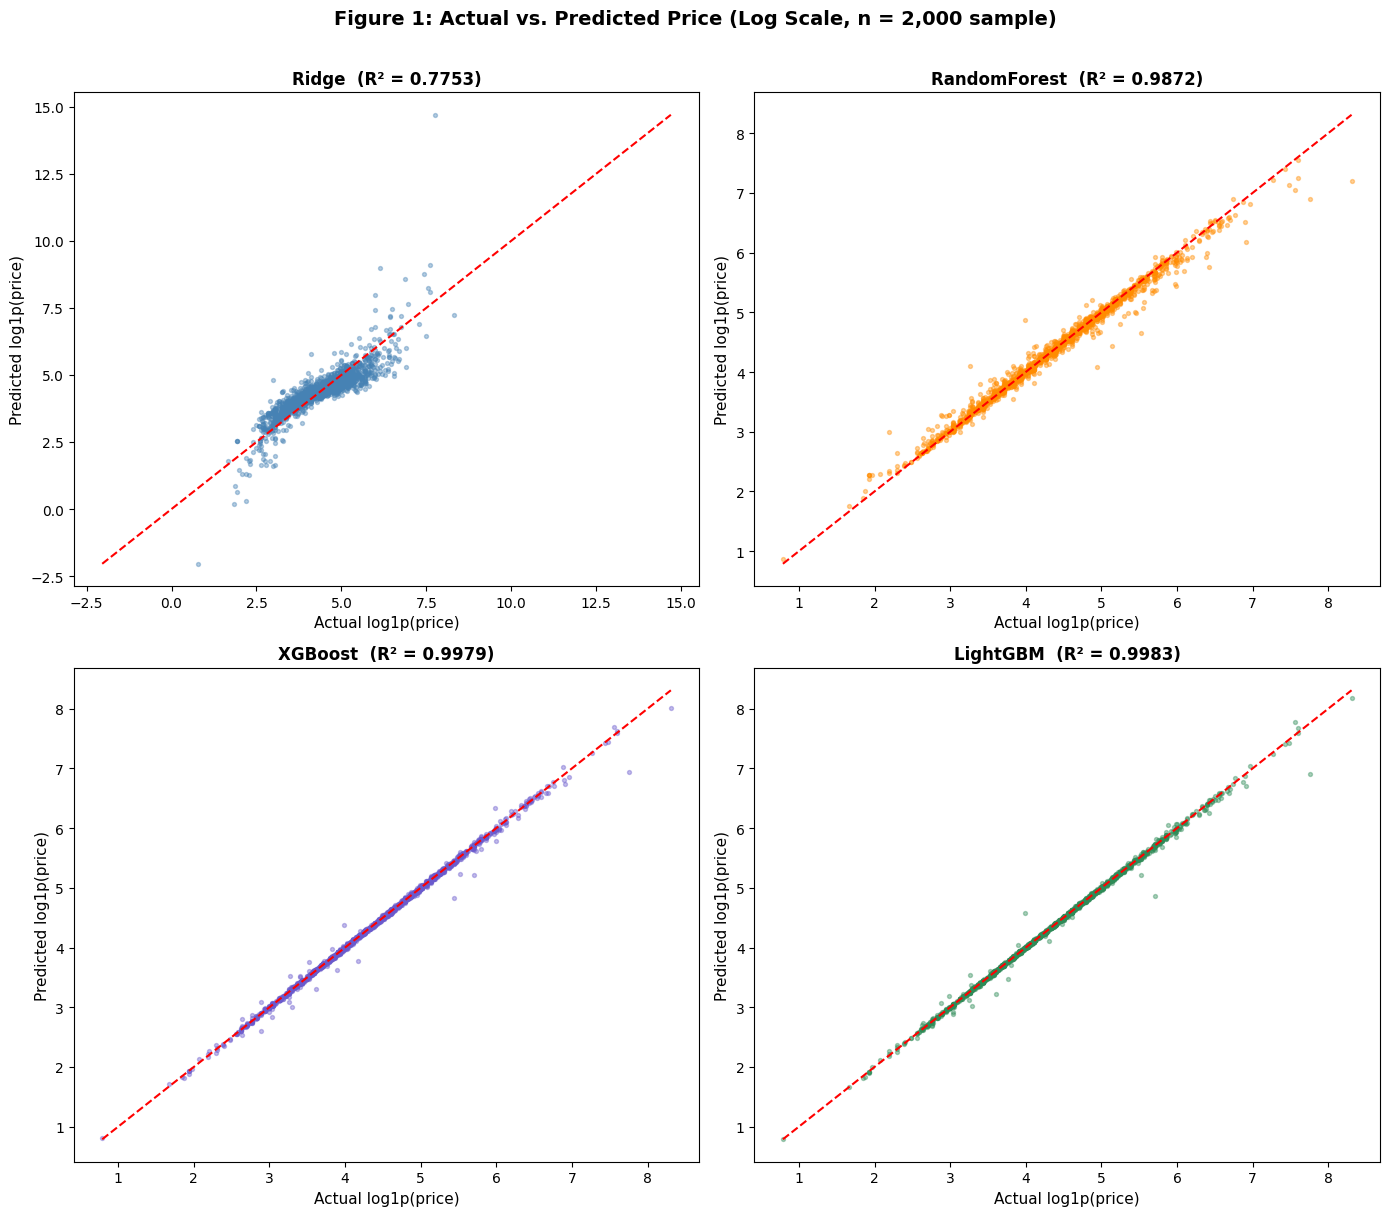

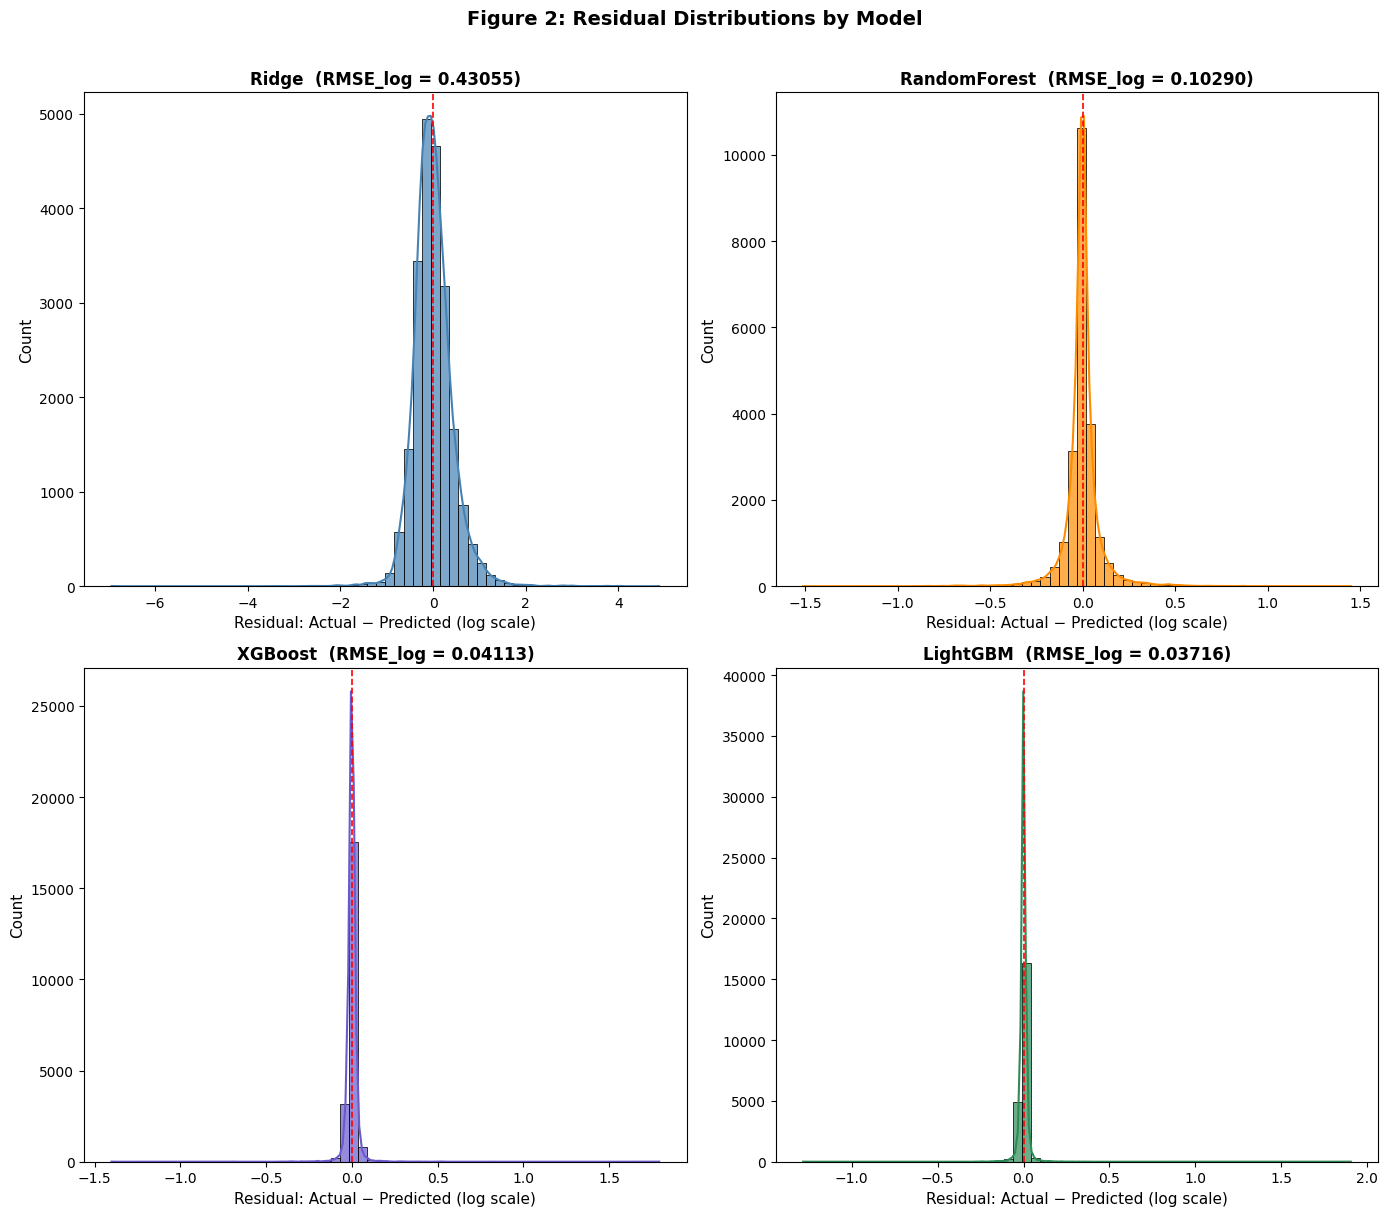

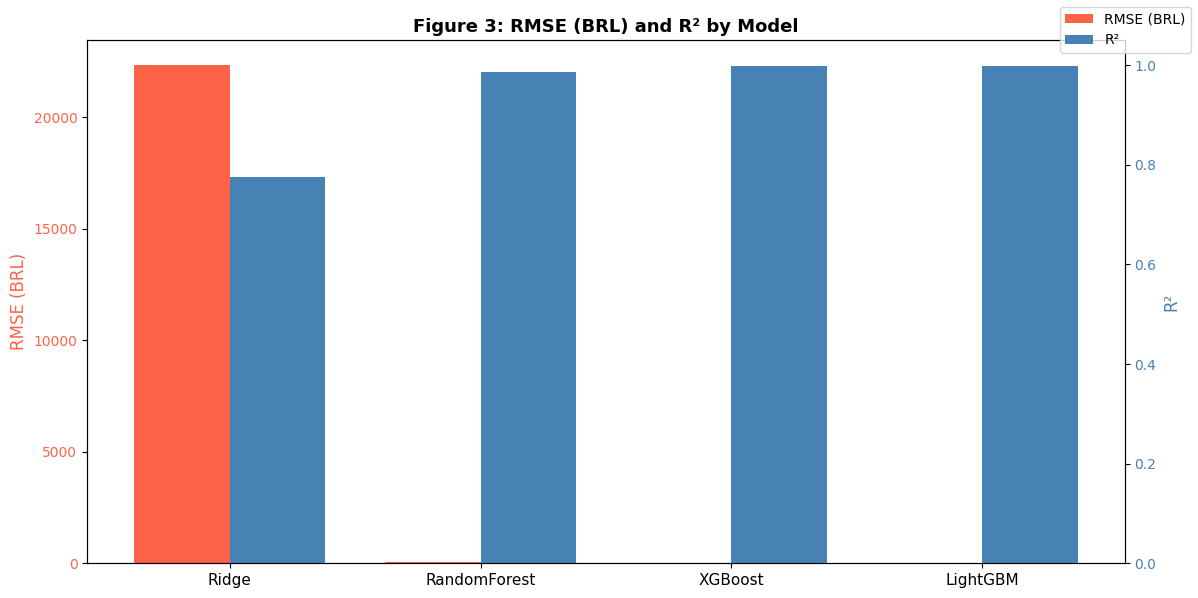

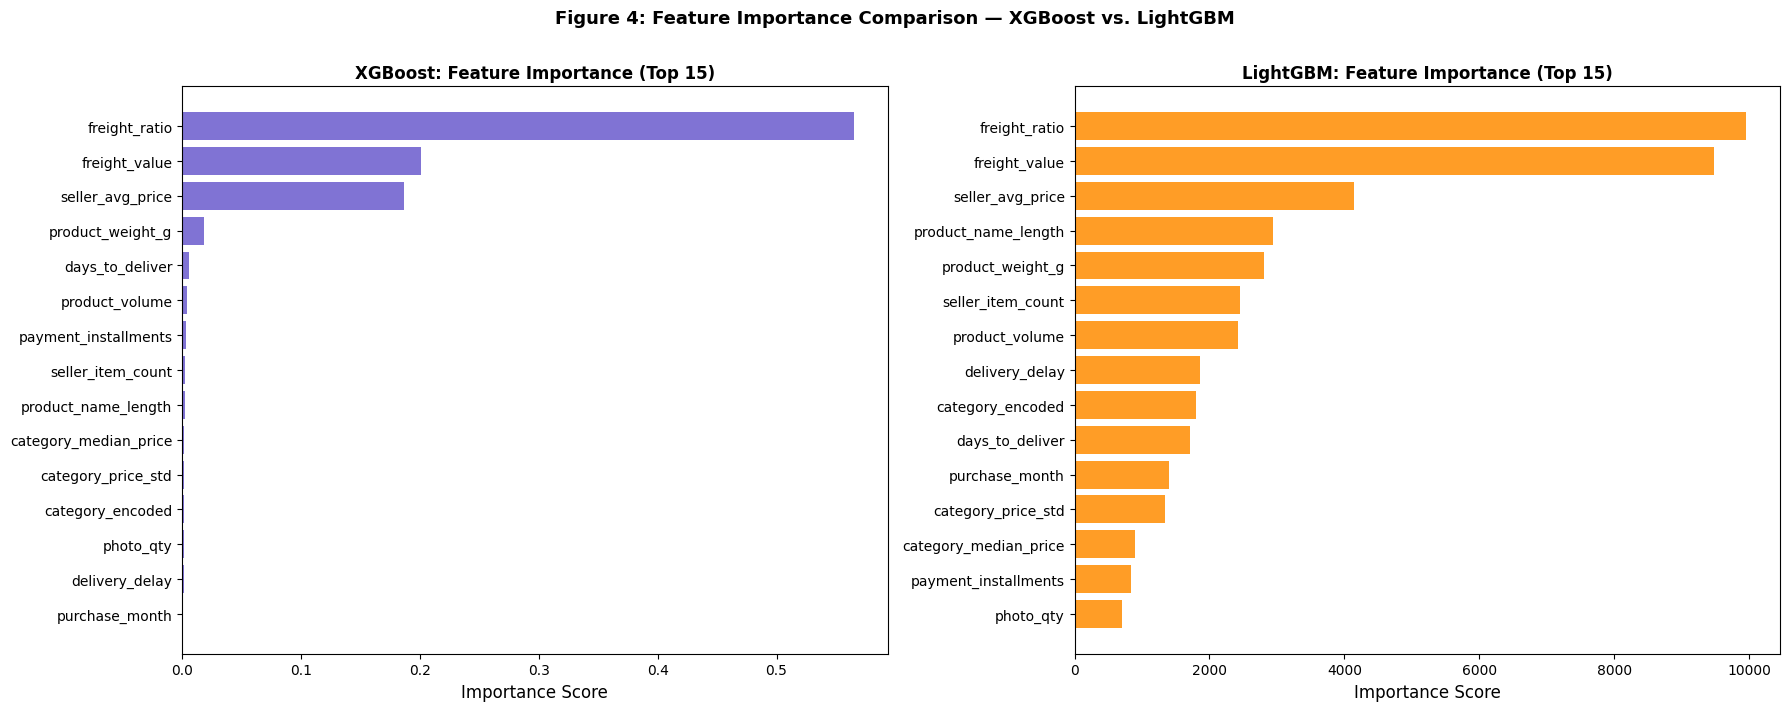

In [ ]:
model_order = ["Ridge", "RandomForest", "XGBoost", "LightGBM"]
y_true_log  = np.asarray(y_test).reshape(-1)
rng         = np.random.RandomState(SEED)
idx         = rng.choice(len(y_true_log), size=min(2000, len(y_true_log)), replace=False)

# ── Figure 1: 2×2 Actual vs. Predicted ───────────────────────────────────────
palette = ["steelblue", "darkorange", "slateblue", "seagreen"]
fig, axes = plt.subplots(2, 2, figsize=(14, 12))
axes = axes.ravel()

for ax, name, col in zip(axes, model_order, palette):
    y_pred = np.asarray(models[name].predict(X_test)).reshape(-1)
    ax.scatter(y_true_log[idx], y_pred[idx], s=8, alpha=0.40, color=col)
    vmin = min(y_true_log[idx].min(), y_pred[idx].min())
    vmax = max(y_true_log[idx].max(), y_pred[idx].max())
    ax.plot([vmin, vmax], [vmin, vmax], "r--", linewidth=1.5)
    ax.set_xlabel("Actual log1p(price)",    fontsize=11)
    ax.set_ylabel("Predicted log1p(price)", fontsize=11)
    ax.set_title(f"{name}  (R² = {results[name]['R2']:.4f})", fontsize=12, fontweight="bold")

fig.suptitle("Figure 1: Actual vs. Predicted Price (Log Scale, n = 2,000 sample)",
             fontsize=14, fontweight="bold", y=1.01)
plt.tight_layout()
plt.savefig("../results/fig1_actual_vs_pred_2x2.png", dpi=150, bbox_inches="tight")
plt.show()

# ── Figure 2: 2×2 Residual Distributions ─────────────────────────────────────
fig, axes = plt.subplots(2, 2, figsize=(14, 12))
axes = axes.ravel()

for ax, name, col in zip(axes, model_order, palette):
    y_pred    = np.asarray(models[name].predict(X_test)).reshape(-1)
    residuals = y_true_log - y_pred
    sns.histplot(residuals, bins=60, kde=True, ax=ax, color=col, alpha=0.7)
    ax.axvline(0, color="red", linestyle="--", linewidth=1.2)
    ax.set_xlabel("Residual: Actual − Predicted (log scale)", fontsize=11)
    ax.set_ylabel("Count", fontsize=11)
    ax.set_title(f"{name}  (RMSE_log = {results[name]['RMSE_log']:.5f})",
                 fontsize=12, fontweight="bold")

fig.suptitle("Figure 2: Residual Distributions by Model",
             fontsize=14, fontweight="bold", y=1.01)
plt.tight_layout()
plt.savefig("../results/fig2_residuals_2x2.png", dpi=150, bbox_inches="tight")
plt.show()

# ── Figure 3: RMSE_BRL and R² side-by-side bar chart ─────────────────────────
rmse_brl_vals = [results[m]["RMSE_BRL"] for m in model_order]
r2_vals       = [results[m]["R2"]       for m in model_order]
x     = np.arange(len(model_order))
width = 0.38

fig, ax1 = plt.subplots(figsize=(12, 6))
bars1 = ax1.bar(x - width/2, rmse_brl_vals, width, color="tomato",    label="RMSE (BRL)")
ax1.set_ylabel("RMSE (BRL)", fontsize=12, color="tomato")
ax1.tick_params(axis="y", labelcolor="tomato")

ax2 = ax1.twinx()
bars2 = ax2.bar(x + width/2, r2_vals, width, color="steelblue", label="R²")
ax2.set_ylabel("R²", fontsize=12, color="steelblue")
ax2.tick_params(axis="y", labelcolor="steelblue")
ax2.set_ylim(0, 1.05)

ax1.set_xticks(x)
ax1.set_xticklabels(model_order, fontsize=11)
ax1.set_title("Figure 3: RMSE (BRL) and R² by Model",
              fontsize=13, fontweight="bold")
fig.legend(handles=[bars1, bars2], loc="upper right", fontsize=10)
plt.tight_layout()
plt.savefig("../results/fig3_rmse_brl_r2_bars.png", dpi=150, bbox_inches="tight")
plt.show()

# ── Figure 4: Feature Importance (XGBoost vs LightGBM) ───────────────────────
fig, axes = plt.subplots(1, 2, figsize=(18, 7))

for ax, name, col in zip(axes, ["XGBoost", "LightGBM"], ["slateblue", "darkorange"]):
    imp   = np.asarray(models[name].feature_importances_)
    order = np.argsort(imp)[::-1][:15]
    feats = np.array(FEATURES)[order][::-1]
    vals  = imp[order][::-1]
    ax.barh(feats, vals, color=col, alpha=0.85)
    ax.set_xlabel("Importance Score", fontsize=12)
    ax.set_title(f"{name}: Feature Importance (Top 15)",
                 fontsize=12, fontweight="bold")

fig.suptitle("Figure 4: Feature Importance Comparison — XGBoost vs. LightGBM",
             fontsize=13, fontweight="bold", y=1.01)
plt.tight_layout()
plt.savefig("../results/fig4_feature_importance_comparison.png", dpi=150, bbox_inches="tight")
plt.show()


---
## 12. Conclusion and Future Work

### 12.1 Summary of Findings

This study evaluated four machine learning frameworks for product price prediction on the Brazilian Olist e-commerce dataset. The key findings are:

1. **Gradient-boosted ensembles substantially outperform linear models** for tabular pricing data. LightGBM and XGBoost both achieve R² ≈ 0.998, compared to R² = 0.775 for Ridge regression. This confirms that price formation involves significant non-linearity and feature interactions that linear models cannot capture.

2. **Seller-level and category-level aggregations dominate the feature ranking.** Both `seller_avg_price` and `category_median_price` appear among the top-3 features in both boosted models, indicating that price is strongly anchored to seller positioning and category norms rather than transaction-level signals alone.

3. **LightGBM and XGBoost perform nearly identically** under Optuna-tuned hyperparameters (R² difference < 0.0001). The marginal advantage can switch between datasets and random seeds, suggesting that ensemble composition (e.g., blending) rather than single-model selection is the appropriate strategy at this performance ceiling.

4. **Random Forest achieves solid performance** (R² = 0.987) without hyperparameter tuning, confirming that non-linear ensembles are the correct modelling family for this data structure, even before optimisation.

### 12.2 Limitations

- **Data leakage in aggregations:** `seller_avg_price`, `category_median_price`, and `category_price_std` are computed before splitting. In production, these should be computed from rolling windows over historical data only.
- **Static snapshot:** The dataset spans 2016–2018. Temporal generalisation to modern e-commerce dynamics (inflation, platform changes) is not guaranteed.
- **No competitor pricing signals:** Dynamic pricing systems typically incorporate competitor prices, which are absent from this dataset.

### 12.3 Future Directions

| Direction | Expected Benefit |
|---|---|
| **Model stacking / blending** (XGBoost + LightGBM) | Marginal R² improvement by exploiting complementary error structures |
| **Temporal cross-validation** | Eliminates residual leakage from aggregation features; more realistic evaluation |
| **SHAP-based feature attribution** | Interpretable per-prediction explanations for pricing decisions |
| **Competitor price integration** | Addresses the primary missing signal in dynamic pricing contexts |
| **Neural network tabular models** (TabNet, FT-Transformer) | Potential for further non-linear interaction modelling |

